In [38]:
import pandas as pd
import numpy as np
import os
from functools import reduce
from scipy import stats
import cvxpy as cp
from datetime import datetime
from collections import defaultdict
import pickle
import lightgbm as lgb
from helpfunc_ml import evaluate_factor
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import QuantileTransformer

srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base"
adir = "E:/SJTU/实习/国泰海通/barra因子/result"
model_dir = "E:/SJTU/实习/国泰海通/barra因子/data_base/lgb_models"
mcp_dict = pd.read_pickle(f"{srcdir}/stk_mcp/全A_freemcp_25_26D_dict.pkl")
return_dict = pd.read_pickle(f"{srcdir}/stk_ret/全A_ret_24_2603D_1030minute_s-1_dict.pkl")
alpha_dict = pd.read_pickle(f"{adir}/延迟alpha/ortho_delay_measures_2024_2026_dict.pkl")


alpha_name = "D1"#"DELAY"#'MACD_HIST'
start_dt = "2024-09-01"
end_dt = "2026-03-25"
trdates = pd.read_pickle(f"{srcdir}/trading_dates.pkl")
tr_filter = [d for d in trdates if (d >= start_dt) and (d <= end_dt)]
window = 60
purge = 5
params = {
        "objective":'regression',
        "boosting_type":"gbdt",
        # 树参数
        "n_estimators":500, 
        "learning_rate":0.03,
        "num_leaves":16, #16 #256
        "max_depth":4, #4 #-1
        # 稳定性
        "random_state":42,
        "n_jobs":16,
        "force_row_wise":True
}
params_orth = {
        "objective":'regression',
        "boosting_type":"gbdt",
        # 树参数
        "n_estimators":500, 
        "learning_rate":0.03,
        "num_leaves":4, #16 #256
        "max_depth":2, #4 #-1,
        "min_data_in_leaf": 5000,
        # 稳定性
        "random_state":42,
        "n_jobs":16,
        "force_row_wise":True
}
#qt = QuantileTransformer(n_quantiles=1000, output_distribution='uniform', random_state=42)
eval_train = {}
eval_valid = {}



for idx, dt in enumerate(tr_filter[window+purge:], start=window+purge):
    # if w0 is None:
    dt_tp = datetime.strptime(dt, "%Y-%m-%d")

    # if (datetime(2025,5,27) <= dt_tp <= datetime(2025,7,10)) or (datetime(2025,10,20) <= dt_tp <= datetime(2026,1,14)):
    #     params["max_depth"] = -1
    #     params["num_leaves"] = 256
    # else:
    #     params["max_depth"] = 4
    #     params["num_leaves"] = 16
    training_dates = tr_filter[idx-window-purge:idx-purge]
    train_dates = training_dates[:-10]
    valid_dates = training_dates[-10:]

    res = []
    for tr_dt in training_dates:
        tr_dt_tp = pd.to_datetime(tr_dt)
        df_alpha = alpha_dict[tr_dt_tp].reset_index()
        df_mcp = mcp_dict[tr_dt_tp][["free_circulation"]]

        tr_dt_tp = tr_dt_tp.replace(hour=10, minute=30, second=0)
        df_ret_tz = return_dict[tr_dt_tp].to_frame()
        df_ret_tz.columns = ["ret_tz"]

        dfs = [df_alpha,df_mcp,df_ret_tz]
        df_t = reduce(lambda left, right: pd.merge(left, right,on="order_book_id",how="inner"), dfs)
        df_t.reset_index(inplace=True)
        df_t["date"] = tr_dt
        res.append(df_t.set_index(['order_book_id', 'date']))
    df_training = pd.concat(res,ignore_index=False)
    df_training.dropna(how="any",inplace=True)

    X = df_training[[alpha_name]]
    Y = df_training["ret_tz"]
    W = df_training["free_circulation"]
    X_train = X[X.index.get_level_values(1).isin(train_dates)]
    #X_train = qt.fit_transform(X_train)
    y_train = Y[Y.index.get_level_values(1).isin(train_dates)]
    sample_weight_train = np.sqrt(W[W.index.get_level_values(1).isin(train_dates)])    
    # 防止极端值
    # sample_weight = sample_weight / sample_weight.median()
    # sample_weight = sample_weight.clip(lower=0.1,upper=10)

    X_valid = X[X.index.get_level_values(1).isin(valid_dates)]
    #X_valid = qt.transform(X_valid)
    y_valid = Y[Y.index.get_level_values(1).isin(valid_dates)]
    sample_weight_valid = np.sqrt(W[W.index.get_level_values(1).isin(valid_dates)])

    train_data = lgb.Dataset(X_train,label=y_train,weight=sample_weight_train)
    valid_data = lgb.Dataset(X_valid,label=y_valid,weight=sample_weight_valid)
    model = lgb.train(params_orth, train_data, valid_sets=[valid_data],
                callbacks=[
            lgb.early_stopping(30),
            lgb.log_evaluation(10)
        ])

    #检查in-sample performance
    eval_train[dt] = evaluate_factor(model.predict(X_train),y_train,sample_weight_train)
    #检查out-of-sample performance
    eval_valid[dt] = evaluate_factor(model.predict(X_valid),y_valid,sample_weight_valid)

    #检查In-sample performance
    pred_train = model.predict(X_train)
    pearson_ic = pearsonr(pred_train,y_train)[0]
    rank_ic = spearmanr(pred_train,y_train)[0]

    ss_res = np.sum((y_train - pred_train) ** 2)
    ss_tot = np.sum((y_train - y_train.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    print(f"train Pearson IC : {pearson_ic:.6f}")
    print(f"train Rank IC    : {rank_ic:.6f}")
    print(f"train R^2        : {r2:.6f}")
    #检查out-of-sample performance
    pred_valid = model.predict(X_valid)
    pearson_ic = pearsonr(pred_valid,y_valid)[0]
    rank_ic = spearmanr(pred_valid,y_valid)[0]

    ss_res = np.sum((y_valid - pred_valid) ** 2)
    ss_tot = np.sum((y_valid - y_valid.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    print(f"Valid Pearson IC : {pearson_ic:.6f}")
    print(f"Valid Rank IC    : {rank_ic:.6f}")
    print(f"Valid R^2        : {r2:.6f}")
    #model_dict[dt] = model

    model_path = f"{model_dir}/{dt}.pkl"
    with open(model_path, "wb") as f:
        pickle.dump(model, f)
    print(f"saved model: {dt}")

#保存eval结果
df = pd.DataFrame.from_dict(eval_train, orient='index')
df.to_excel(f"{model_dir}/eval/train评估结果_robust.xlsx", index_label='dt')
df = pd.DataFrame.from_dict(eval_valid, orient='index')
df.to_excel(f"{model_dir}/eval/valid评估结果_robust.xlsx", index_label='dt')


[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 251700, number of used features: 1
[LightGBM] [Info] Start training from score 0.006411
Training until validation scores don't improve for 30 rounds
[10]	valid_0's l2: 0.00117341
[20]	valid_0's l2: 0.00117319
[30]	valid_0's l2: 0.00117312
[40]	valid_0's l2: 0.00117309
[50]	valid_0's l2: 0.00117309
[60]	valid_0's l2: 0.0011731
[70]	valid_0's l2: 0.00117311
[80]	valid_0's l2: 0.00117312
Early stopping, best iteration is:
[52]	valid_0's l2: 0.00117309
train Pearson IC : 0.027855
train Rank IC    : 0.013077
train R^2        : 0.000699
Valid Pearson IC : 0.016376
Valid Rank IC    : 0.012100
Valid R^2        : -0.003950
saved model: 2024-12-11
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 251712, number of used features: 1
[LightGBM] [Info] Start training from score 0.006722
Training until validation scores don't improve for 30 rounds
[10]	valid_0's l2: 0.00

In [10]:
df_eval = pd.DataFrame({

    "pred": pred_train,
    "ret": y_train.values

})

df_eval["group"] = pd.qcut(
    df_eval["pred"],
    10,
    labels=False,
    duplicates='drop'
)

group_ret = (
    df_eval
    .groupby("group")["ret"]
    .mean()
)

# long-short
ls_ret = (
    group_ret.iloc[-1]
    - group_ret.iloc[0]
)

print(f"Train Long-Short : {ls_ret:.6f}")

print("\nGroup Return:")

print(group_ret)

print("=" * 60)

Train Long-Short : 0.004484

Group Return:
group
0    0.005322
1    0.006379
2    0.006509
3    0.007027
4    0.007692
5    0.007625
6    0.007913
7    0.008600
8    0.009063
9    0.009806
Name: ret, dtype: float64


In [11]:
df_eval = pd.DataFrame({

    "pred": pred_valid,
    "ret": y_valid.values

})

df_eval["group"] = pd.qcut(
    df_eval["pred"],
    10,
    labels=False,
    duplicates='drop'
)

group_ret = (
    df_eval
    .groupby("group")["ret"]
    .mean()
)

# long-short
ls_ret = (
    group_ret.iloc[-1]
    - group_ret.iloc[0]
)

print(f"Train Long-Short : {ls_ret:.6f}")

print("\nGroup Return:")

print(group_ret)

print("=" * 60)

Train Long-Short : 0.002234

Group Return:
group
0    0.002037
1    0.004179
2    0.003858
3    0.003853
4    0.004273
5    0.004462
6    0.004276
7    0.004237
8    0.004791
9    0.004272
Name: ret, dtype: float64


In [5]:
import pandas as pd
import numpy as np
import os
from functools import reduce
from scipy import stats
import cvxpy as cp
from datetime import datetime
from collections import defaultdict
import pickle
import lightgbm as lgb
from helpfunc_ml import evaluate_factor
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import QuantileTransformer

srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base"
adir = "E:/SJTU/实习/国泰海通/barra因子/result"
model_dir = "E:/SJTU/实习/国泰海通/barra因子/data_base/lgb_models"
mcp_dict = pd.read_pickle(f"{srcdir}/stk_mcp/全A_freemcp_25_26D_dict.pkl")
return_dict = pd.read_pickle(f"{srcdir}/stk_ret/全A_ret_24_2603D_1030minute_s-1_dict.pkl")
alpha_dict = pd.read_pickle(f"{adir}/延迟alpha/ortho_delay_measures_2024_2026_dict.pkl")


alpha_name = "D1"#"DELAY"#'MACD_HIST'
start_dt = "2024-09-01"
end_dt = "2026-03-25"
trdates = pd.read_pickle(f"{srcdir}/trading_dates.pkl")
tr_filter = [d for d in trdates if (d >= start_dt) and (d <= end_dt)]
window = 60
purge = 5
params = {
        "objective":'regression',
        "boosting_type":"gbdt",
        # 树参数
        "n_estimators":500, 
        "learning_rate":0.03,
        "num_leaves":16, #16 #256
        "max_depth":4, #4 #-1
        # 稳定性
        "random_state":42,
        "n_jobs":16,
        "force_row_wise":True
}
params_orth = {
        "objective":'regression',
        "boosting_type":"gbdt",
        # 树参数
        "n_estimators":500, 
        "learning_rate":0.03,
        "num_leaves":4, #16 #256
        "max_depth":2, #4 #-1,
        "min_data_in_leaf": 5000,
        # 稳定性
        "random_state":42,
        "n_jobs":16,
        "force_row_wise":True
}
#qt = QuantileTransformer(n_quantiles=1000, output_distribution='uniform', random_state=42)
eval_train = {}
eval_valid = {}

import optuna
import lightgbm as lgb
import numpy as np
from scipy.stats import spearmanr


def objective(trial):

    params_opt = {
        "objective":"regression",
        "metric":None,
        "boosting_type":"gbdt",
        "n_estimators":500, 

        "learning_rate":trial.suggest_float(
            "learning_rate", 0.01, 0.05, log=True
        ),

        "num_leaves":trial.suggest_int(
            "num_leaves", 4, 32
        ),

        "max_depth":trial.suggest_int(
            "max_depth", 2, 5
        ),

        "min_data_in_leaf":trial.suggest_int(
            "min_data_in_leaf", 1000, 10000
        ),

        "lambda_l1":trial.suggest_float(
            "lambda_l1", 1e-3, 5, log=True
        ),

        "lambda_l2":trial.suggest_float(
            "lambda_l2", 1e-3, 10, log=True
        ),

        "bagging_fraction":trial.suggest_float(
            "bagging_fraction", 0.6, 1.0
        ),

        "bagging_freq":1,

        "feature_pre_filter":False,
        "random_state":42,
        "n_jobs":16,
        "force_row_wise":True,
        "verbosity":-1
    }

    model = lgb.train(
        params_opt,
        train_data,
        valid_sets=[valid_data],
        callbacks=[
            lgb.early_stopping(30),
            lgb.log_evaluation(0)
        ]
    )

    daily_ic = []

    valid_dates = X_valid.index.get_level_values(1).unique()
    for vd in valid_dates:

        mask = (
            X_valid.index.get_level_values(1) == vd
        )

        pred = model.predict(X_valid[mask])

        y_true = y_valid[mask]

        ic = spearmanr(pred, y_true)[0]

        if not np.isnan(ic):
            daily_ic.append(ic)

    daily_ic = np.array(daily_ic)

    if len(daily_ic) <= 1:
        return -999

    ic_mean = daily_ic.mean()

    ic_std = daily_ic.std()

    if ic_std == 0:
        return -999

    icir = ic_mean / ic_std

    return icir

# =========================
# optuna只做一次搜参
# =========================

idx0 = window + purge
training_dates = tr_filter
train_dates = training_dates[:-60]
valid_dates = training_dates[-60:]
res = []

for tr_dt in training_dates:
    tr_dt_tp = pd.to_datetime(tr_dt)
    df_alpha = alpha_dict[tr_dt_tp].reset_index()
    df_mcp = mcp_dict[tr_dt_tp][["free_circulation"]]
    tr_dt_tp = tr_dt_tp.replace(hour=10,minute=30,second=0
                                )
    df_ret_tz = return_dict[tr_dt_tp].to_frame()
    df_ret_tz.columns = ["ret_tz"]
    dfs = [df_alpha, df_mcp, df_ret_tz]
    df_t = reduce(lambda left, right:pd.merge(
            left,
            right,
            on="order_book_id",
            how="inner"
        ),dfs)

    df_t.reset_index(inplace=True)
    df_t["date"] = tr_dt
    res.append(df_t.set_index(['order_book_id', 'date']))

df_training = pd.concat(res, ignore_index=False)
df_training.dropna(how="any", inplace=True)
X = df_training[[alpha_name]]
Y = df_training["ret_tz"]
W = df_training["free_circulation"]
X_train = X[X.index.get_level_values(1).isin(train_dates)]
y_train = Y[Y.index.get_level_values(1).isin(train_dates)]
sample_weight_train = np.sqrt(
    W[W.index.get_level_values(1).isin(train_dates)]
)

X_valid = X[X.index.get_level_values(1).isin(valid_dates)]
y_valid = Y[Y.index.get_level_values(1).isin(valid_dates)]
sample_weight_valid = np.sqrt(
    W[W.index.get_level_values(1).isin(valid_dates)]
)

train_data = lgb.Dataset(X_train,label=y_train,weight=sample_weight_train)
valid_data = lgb.Dataset(X_valid,label=y_valid,weight=sample_weight_valid)

study = optuna.create_study(direction="maximize")

study.optimize(objective,n_trials=100)

best_params = study.best_params
print(best_params)
params_orth.update(best_params)

best_value = study.best_value
print(best_value)

print(study.best_trial)
study.trials_dataframe()


# for idx, dt in enumerate(tr_filter[window+purge:], start=window+purge):
#     # if w0 is None:
#     dt_tp = datetime.strptime(dt, "%Y-%m-%d")

#     # if (datetime(2025,5,27) <= dt_tp <= datetime(2025,7,10)) or (datetime(2025,10,20) <= dt_tp <= datetime(2026,1,14)):
#     #     params["max_depth"] = -1
#     #     params["num_leaves"] = 256
#     # else:
#     #     params["max_depth"] = 4
#     #     params["num_leaves"] = 16
#     training_dates = tr_filter[idx-window-purge:idx-purge]
#     train_dates = training_dates[:-10]
#     valid_dates = training_dates[-10:]

#     res = []
#     for tr_dt in training_dates:
#         tr_dt_tp = pd.to_datetime(tr_dt)
#         df_alpha = alpha_dict[tr_dt_tp].reset_index()
#         df_mcp = mcp_dict[tr_dt_tp][["free_circulation"]]

#         tr_dt_tp = tr_dt_tp.replace(hour=10, minute=30, second=0)
#         df_ret_tz = return_dict[tr_dt_tp].to_frame()
#         df_ret_tz.columns = ["ret_tz"]

#         dfs = [df_alpha,df_mcp,df_ret_tz]
#         df_t = reduce(lambda left, right: pd.merge(left, right,on="order_book_id",how="inner"), dfs)
#         df_t.reset_index(inplace=True)
#         df_t["date"] = tr_dt
#         res.append(df_t.set_index(['order_book_id', 'date']))
#     df_training = pd.concat(res,ignore_index=False)
#     df_training.dropna(how="any",inplace=True)

#     X = df_training[[alpha_name]]
#     Y = df_training["ret_tz"]
#     W = df_training["free_circulation"]
#     X_train = X[X.index.get_level_values(1).isin(train_dates)]
#     #X_train = qt.fit_transform(X_train)
#     y_train = Y[Y.index.get_level_values(1).isin(train_dates)]
#     sample_weight_train = np.sqrt(W[W.index.get_level_values(1).isin(train_dates)])    
#     # 防止极端值
#     # sample_weight = sample_weight / sample_weight.median()
#     # sample_weight = sample_weight.clip(lower=0.1,upper=10)

#     X_valid = X[X.index.get_level_values(1).isin(valid_dates)]
#     #X_valid = qt.transform(X_valid)
#     y_valid = Y[Y.index.get_level_values(1).isin(valid_dates)]
#     sample_weight_valid = np.sqrt(W[W.index.get_level_values(1).isin(valid_dates)])

#     train_data = lgb.Dataset(X_train,label=y_train,weight=sample_weight_train)
#     valid_data = lgb.Dataset(X_valid,label=y_valid,weight=sample_weight_valid)
#     model = lgb.train(params_orth, train_data, valid_sets=[valid_data],
#                 callbacks=[
#             lgb.early_stopping(30),
#             lgb.log_evaluation(10)
#         ])

#     #检查in-sample performance
#     eval_train[dt] = evaluate_factor(model.predict(X_train),y_train,sample_weight_train)
#     #检查out-of-sample performance
#     eval_valid[dt] = evaluate_factor(model.predict(X_valid),y_valid,sample_weight_valid)

#     #检查In-sample performance
#     pred_train = model.predict(X_train)
#     pearson_ic = pearsonr(pred_train,y_train)[0]
#     rank_ic = spearmanr(pred_train,y_train)[0]

#     ss_res = np.sum((y_train - pred_train) ** 2)
#     ss_tot = np.sum((y_train - y_train.mean()) ** 2)
#     r2 = 1 - ss_res / ss_tot

#     print(f"train Pearson IC : {pearson_ic:.6f}")
#     print(f"train Rank IC    : {rank_ic:.6f}")
#     print(f"train R^2        : {r2:.6f}")
#     #检查out-of-sample performance
#     pred_valid = model.predict(X_valid)
#     pearson_ic = pearsonr(pred_valid,y_valid)[0]
#     rank_ic = spearmanr(pred_valid,y_valid)[0]

#     ss_res = np.sum((y_valid - pred_valid) ** 2)
#     ss_tot = np.sum((y_valid - y_valid.mean()) ** 2)
#     r2 = 1 - ss_res / ss_tot

#     print(f"Valid Pearson IC : {pearson_ic:.6f}")
#     print(f"Valid Rank IC    : {rank_ic:.6f}")
#     print(f"Valid R^2        : {r2:.6f}")
#     #model_dict[dt] = model

#     model_path = f"{model_dir}/{dt}.pkl"
#     with open(model_path, "wb") as f:
#         pickle.dump(model, f)
#     print(f"saved model: {dt}")

# #保存eval结果
# df = pd.DataFrame.from_dict(eval_train, orient='index')
# df.to_excel(f"{model_dir}/eval/train评估结果_robust.xlsx", index_label='dt')
# df = pd.DataFrame.from_dict(eval_valid, orient='index')
# df.to_excel(f"{model_dir}/eval/valid评估结果_robust.xlsx", index_label='dt')


[I 2026-05-25 20:07:51,239] A new study created in memory with name: no-name-0cd7f0a0-7895-4898-b04d-66eb3ce5e4c4


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[445]	valid_0's l2: 0.000883354


[I 2026-05-25 20:07:56,161] Trial 0 finished with value: 0.21331171378766872 and parameters: {'learning_rate': 0.011442877086287192, 'num_leaves': 9, 'max_depth': 3, 'min_data_in_leaf': 1638, 'lambda_l1': 4.608039890518838, 'lambda_l2': 0.011437014082305047, 'bagging_fraction': 0.9277525790379094}. Best is trial 0 with value: 0.21331171378766872.


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[218]	valid_0's l2: 0.000883347


[I 2026-05-25 20:07:59,571] Trial 1 finished with value: 0.21372613535211674 and parameters: {'learning_rate': 0.019296192256698506, 'num_leaves': 12, 'max_depth': 3, 'min_data_in_leaf': 6513, 'lambda_l1': 2.837966903566521, 'lambda_l2': 4.423323417121996, 'bagging_fraction': 0.8538361334121618}. Best is trial 1 with value: 0.21372613535211674.


...

[I 2026-05-25 20:12:47,227] Trial 98 finished with value: 0.21388086605659554 and parameters: {'learning_rate': 0.028641353940139884, 'num_leaves': 10, 'max_depth': 5, 'min_data_in_leaf': 7994, 'lambda_l1': 1.4671147755711376, 'lambda_l2': 0.0027185957967176765, 'bagging_fraction': 0.635928622119395}. Best is trial 72 with value: 0.21801358011274258.


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[116]	valid_0's l2: 0.000883366


[I 2026-05-25 20:12:50,105] Trial 99 finished with value: 0.21312670779705822 and parameters: {'learning_rate': 0.03685781975845174, 'num_leaves': 18, 'max_depth': 5, 'min_data_in_leaf': 7592, 'lambda_l1': 0.0763090561244876, 'lambda_l2': 0.010061695319962935, 'bagging_fraction': 0.858213987688806}. Best is trial 72 with value: 0.21801358011274258.


{'learning_rate': 0.039839554708118625, 'num_leaves': 13, 'max_depth': 5, 'min_data_in_leaf': 8361, 'lambda_l1': 0.8901791124223084, 'lambda_l2': 0.07660255569647859, 'bagging_fraction': 0.6099913161354305}
0.21801358011274258
FrozenTrial(number=72, state=<TrialState.COMPLETE: 1>, values=[0.21801358011274258], datetime_start=datetime.datetime(2026, 5, 25, 20, 11, 27, 154255), datetime_complete=datetime.datetime(2026, 5, 25, 20, 11, 29, 928048), params={'learning_rate': 0.039839554708118625, 'num_leaves': 13, 'max_depth': 5, 'min_data_in_leaf': 8361, 'lambda_l1': 0.8901791124223084, 'lambda_l2': 0.07660255569647859, 'bagging_fraction': 0.6099913161354305}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'learning_rate': FloatDistribution(high=0.05, log=True, low=0.01, step=None), 'num_leaves': IntDistribution(high=32, log=False, low=4, step=1), 'max_depth': IntDistribution(high=5, log=False, low=2, step=1), 'min_data_in_leaf': IntDistribution(high=10000, log=False

,number,value,datetime_start,datetime_complete,duration,params_bagging_fraction,params_lambda_l1,params_lambda_l2,params_learning_rate,params_max_depth,params_min_data_in_leaf,params_num_leaves,state
0,0,0.213312,2026-05-25 20:07:51.239706,2026-05-25 20:07:56.161831,0 days 00:00:04.922125,0.927753,4.608040,0.011437,0.011443,3,1638,9,COMPLETE
1,1,0.213726,2026-05-25 20:07:56.163845,2026-05-25 20:07:59.571455,0 days 00:00:03.407610,0.853836,2.837967,4.423323,0.019296,3,6513,12,COMPLETE
2,2,0.214860,2026-05-25 20:07:59.572458,2026-05-25 20:08:03.106654,0 days 00:00:03.534196,0.783848,0.113221,0.043914,0.021842,2,7888,31,COMPLETE
3,3,0.215365,2026-05-25 20:08:03.107654,2026-05-25 20:08:05.578678,0 days 00:00:02.471024,0.798821,0.014268,0.004016,0.044551,4,8056,11,COMPLETE
4,4,0.212084,2026-05-25 20:08:05.579186,2026-05-25 20:08:08.565596,0 days 00:00:02.986410,0.820645,0.016909,0.007569,0.025255,5,2236,22,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,0.214261,2026-05-25 20:12:35.207259,2026-05-25 20:12:38.299227,0 days 00:00:03.091968,0.617304,0.159149,0.019536,0.033450,5,9631,14,COMPLETE
96,96,0.216122,2026-05-25 20:12:38.299536,2026-05-25 20:12:41.173276,0 days 00:00:02.873740,0.600484,0.192981,0.013162,0.031824,5,9086,12,COMPLETE
97,97,0.217480,2026-05-25 20:12:41.174276,2026-05-25 20:12:43.931531,0 days 00:00:02.757255,0.633765,0.352084,0.011338,0.035445,5,8062,10,COMPLETE
98,98,0.213881,2026-05-25 20:12:43.933042,2026-05-25 20:12:47.227777,0 days 00:00:03.294735,0.635929,1.467115,0.002719,0.028641,5,7994,10,COMPLETE


In [6]:
best_params

{'learning_rate': 0.039839554708118625,
 'num_leaves': 13,
 'max_depth': 5,
 'min_data_in_leaf': 8361,
 'lambda_l1': 0.8901791124223084,
 'lambda_l2': 0.07660255569647859,
 'bagging_fraction': 0.6099913161354305}

In [ ]:
best_value = study.best_value
print(best_value)


0.21801358011274258
FrozenTrial(number=72, state=<TrialState.COMPLETE: 1>, values=[0.21801358011274258], datetime_start=datetime.datetime(2026, 5, 25, 20, 11, 27, 154255), datetime_complete=datetime.datetime(2026, 5, 25, 20, 11, 29, 928048), params={'learning_rate': 0.039839554708118625, 'num_leaves': 13, 'max_depth': 5, 'min_data_in_leaf': 8361, 'lambda_l1': 0.8901791124223084, 'lambda_l2': 0.07660255569647859, 'bagging_fraction': 0.6099913161354305}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'learning_rate': FloatDistribution(high=0.05, log=True, low=0.01, step=None), 'num_leaves': IntDistribution(high=32, log=False, low=4, step=1), 'max_depth': IntDistribution(high=5, log=False, low=2, step=1), 'min_data_in_leaf': IntDistribution(high=10000, log=False, low=1000, step=1), 'lambda_l1': FloatDistribution(high=5.0, log=True, low=0.001, step=None), 'lambda_l2': FloatDistribution(high=10.0, log=True, low=0.001, step=None), 'bagging_fraction': FloatDistribution

,number,value,datetime_start,datetime_complete,duration,params_bagging_fraction,params_lambda_l1,params_lambda_l2,params_learning_rate,params_max_depth,params_min_data_in_leaf,params_num_leaves,state
0,0,0.213312,2026-05-25 20:07:51.239706,2026-05-25 20:07:56.161831,0 days 00:00:04.922125,0.927753,4.608040,0.011437,0.011443,3,1638,9,COMPLETE
1,1,0.213726,2026-05-25 20:07:56.163845,2026-05-25 20:07:59.571455,0 days 00:00:03.407610,0.853836,2.837967,4.423323,0.019296,3,6513,12,COMPLETE
2,2,0.214860,2026-05-25 20:07:59.572458,2026-05-25 20:08:03.106654,0 days 00:00:03.534196,0.783848,0.113221,0.043914,0.021842,2,7888,31,COMPLETE
3,3,0.215365,2026-05-25 20:08:03.107654,2026-05-25 20:08:05.578678,0 days 00:00:02.471024,0.798821,0.014268,0.004016,0.044551,4,8056,11,COMPLETE
4,4,0.212084,2026-05-25 20:08:05.579186,2026-05-25 20:08:08.565596,0 days 00:00:02.986410,0.820645,0.016909,0.007569,0.025255,5,2236,22,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,0.214261,2026-05-25 20:12:35.207259,2026-05-25 20:12:38.299227,0 days 00:00:03.091968,0.617304,0.159149,0.019536,0.033450,5,9631,14,COMPLETE
96,96,0.216122,2026-05-25 20:12:38.299536,2026-05-25 20:12:41.173276,0 days 00:00:02.873740,0.600484,0.192981,0.013162,0.031824,5,9086,12,COMPLETE
97,97,0.217480,2026-05-25 20:12:41.174276,2026-05-25 20:12:43.931531,0 days 00:00:02.757255,0.633765,0.352084,0.011338,0.035445,5,8062,10,COMPLETE
98,98,0.213881,2026-05-25 20:12:43.933042,2026-05-25 20:12:47.227777,0 days 00:00:03.294735,0.635929,1.467115,0.002719,0.028641,5,7994,10,COMPLETE


组合优化

In [3]:
import pandas as pd
import numpy as np
import os
from functools import reduce
from scipy import stats
import cvxpy as cp
from datetime import datetime
from collections import defaultdict
import pickle

srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base"
adir = "E:/SJTU/实习/国泰海通/barra因子/result"
spedir = "E:/SJTU/实习/国泰海通/barra因子/result"
model_dir = "E:/SJTU/实习/国泰海通/barra因子/data_base/lgb_models"
mcp_dict = pd.read_pickle(f"{srcdir}/stk_mcp/全A_freemcp_25_26D_dict.pkl")
alpha_dict = pd.read_pickle(f"{adir}/延迟alpha/ortho_delay_measures_2024_2026_dict.pkl")
return_dict = pd.read_pickle(f"{srcdir}/stk_ret/全A_ret_24_2603D_1030minute_s-1_dict.pkl")
trdates = pd.read_pickle(f"{srcdir}/trading_dates.pkl")



def orthogonalize_pair(df, col1, col2, standardize=False):
    x1 = df[col1].values
    x2 = df[col2].values
    # 去均值（等价于带截距回归）
    x1_mean = x1.mean()
    x2_mean = x2.mean()
    x1_c = x1 - x1_mean
    x2_c = x2 - x2_mean
    # OLS beta
    beta1 = np.dot(x1_c, x2_c) / np.dot(x1_c, x1_c)
    beta0 = x2_mean - beta1 * x1_mean
    # 残差（正交部分）
    x2_res = x2 - beta0 - beta1 * x1
    df.loc[:, col2] = x2_res
    return df

#num_ori = 100
start_dt = "2025-01-02"
end_dt = "2026-03-25"
alpha_name = "D1_orth"
tr_filter_op = [d for d in trdates if (d >= start_dt) and (d <= end_dt)]#["2026-01-27","2026-01-28"]#[d for d in trdates if (d >= start_dt) and (d <= end_dt)]
pair_lst = [['earnings_yield', 'liquidity'],['beta', 'residual_volatility'],['non_linear_size', 'size']]
rou_list = [-0.308,0.357,0.510] #根据pair_lst去查数
with open(f"{srcdir}/index_component_日频/000905.XSHG_20_26D_dict.pkl", 'rb') as f:
    weight_dict = pickle.load(f) #series

ret_dict = defaultdict(list)#{}
dual_dict = defaultdict(list) #测试lam取值的时候改！
error_dt = defaultdict(list)
group_ret_hist = []
lam_lst = []
reg_lst = []


for idx,dt in enumerate(tr_filter_op):
    if idx == 0:
        continue
    #明确时间域
    alpha_dt_tp = pd.to_datetime(dt)
    ret_dt_tp = alpha_dt_tp + pd.Timedelta(hours=10) + pd.Timedelta(minutes=30)
    barra_dt = tr_filter_op[idx-1]
    barra_dt_tp = pd.to_datetime(barra_dt)
    print(f"在{dt}天早上决策，10：30买入，第二天10：30卖出")

    #读取数据，最优化
    df_ret = return_dict[ret_dt_tp]
    df_ret.name = "ret"
    df_alpha = alpha_dict[alpha_dt_tp]
    
    df_barra = pd.read_pickle(f"{srcdir}/barra_data/whole_mkt/{barra_dt}.pkl") #000905标准化2
    X_center = pd.read_pickle(f"{srcdir}/barra_data/000905标准化3_含行业/{barra_dt}.pkl") #
    variance_frq = pd.read_pickle(f"{srcdir}/fac_ret_cov/{barra_dt}.pkl")
    variance_rq = pd.read_pickle(f"{srcdir}/spe_ret_cov/{barra_dt}.pkl")
    weight_index = weight_dict[barra_dt_tp]

    #统一顺序
    dfs = [df_alpha,df_ret,df_barra]
    df = reduce(lambda left, right: pd.merge(left, right, on="order_book_id", how="inner"), dfs)
    df = df.merge(weight_index,on="order_book_id",how="left")
    weight_bmk = df["weight"].fillna(0)

    
    # === Step 3: 预测当前 Rhat ===
    model_path = f"{model_dir}/{alpha_name}/{dt}.pkl"
    with open(model_path, "rb") as f:
        model = pickle.load(f)
    Rhat = model.predict(df[[alpha_name]])
    
    ###微调
    Num = len(df)
    # Rhat = np.zeros(Num)

    orth_order = [x for x in variance_frq.index.tolist()[:11] if x != "comovement"]#["beta","momentum","size","non_linear_size","residual_volatility","liquidity","book_to_price","earnings_yield","growth","leverage"]
    ind_order = list(variance_frq.columns[11:].values)
    X_original = df[orth_order+ind_order].values #风格+行业
    stk_order = df["order_book_id"].tolist()
    # #部分正交化
    flat_pair = [item for sublist in pair_lst for item in sublist]
    non_orth = [var for var in orth_order if var not in flat_pair] #['book_to_price', 'growth', 'leverage', 'momentum']
    num_non = len(non_orth) #non_orth + ind_order / non_orth
    X_center_f =X_center.set_index("order_book_id").loc[stk_order, non_orth + flat_pair] #ind_order + 
    X_center_ind = X_center.set_index("order_book_id").loc[stk_order, ind_order].values #行业
    #X_center_bb = X_center.copy()
    for c1, c2 in pair_lst:
        X_center_f = orthogonalize_pair(X_center_f, c1, c2)
    
    X_center = X_center_f.values
    # X_center = X_center.set_index("order_book_id").loc[stk_order,orth_order].values #风格

    # w_m = np.sqrt(df_reg.free_mkp.values)
    # w_m = w_m / w_m.sum()
    #X_orth = weighted_orthogonize(X_ori,w_m)
    #F_cov = variance_frq.loc[orth_order + ind_order, orth_order + ind_order].values#orthogonized_factor_cov(X_orth,w_m)
    #D_diag = variance_rq.reindex(df_reg["code"]).values.ravel()
    #sqrtD = np.sqrt(D_diag)

    #根据barra做进一步完善
    F_cov_raw = variance_frq.loc[orth_order + ind_order, orth_order + ind_order].values
    diag = np.diag(np.diag(F_cov_raw))
    F_cov = 0.9 * F_cov_raw + 0.1 * diag
    D_diag = variance_rq.reindex(df["order_book_id"]).values.ravel()
    lower = np.percentile(D_diag, 1)
    upper = np.percentile(D_diag, 99)
    D_diag = np.clip(D_diag, lower, upper)
    sqrtD = np.sqrt(D_diag)
    w0 = np.ones(len(D_diag)) / len(D_diag)
    risk = w0 @ X_original @ F_cov @ X_original.T @ w0 + w0 @ np.diag(D_diag) @ w0
    ret  = np.mean(np.abs(Rhat))
    lam0 = ret / risk
    lam_lst.append(lam0)
    print(f"{dt}选择的lam：{lam0}")

    #R_cov = X_orth @ F_cov @ X_orth.T
    #设置权重向量的初始值【根据因子信号/等权】
    # w_ori = np.zeros_like(Rhat)
    # idx = np.argsort(Rhat)[::-1][:num_ori]
    # w_ori[idx] = np.exp(-np.arange(num_ori)/20)
    # w_ori /= w_ori.sum()

    print(f"\n=======  开始最优化 {dt} 组合  |  {datetime.now()}  =======\n")
    #turnover = 0.005
    w = cp.Variable(Num)
    w.value = np.zeros(Num) #np.zeros_like(Rhat)
    Xo = X_original.T @ w
    Xp = X_center.T @  (w + weight_bmk)
    Xi = X_center_ind.T @ (w + weight_bmk)
    lam = cp.Parameter(nonneg=True,value=lam0) #lam0
    #penalty = cp.sum_squares(cp.pos(Xp - x_max)) + cp.sum_squares(cp.pos(x_min - Xp))
    #gamma = cp.Parameter(nonneg=True)
    
    objective = cp.Minimize(
            lam * (cp.quad_form(Xo, F_cov) + cp.sum_squares(cp.multiply(sqrtD, w))) - cp.sum(cp.multiply(Rhat, w)) #+ gamma*penalty
        )

    for l_val in [0.01,0.1,0.3,0.5,1]:#[0.01,0.1,0.3,0.5,1]:
        #gamma.value = l_val
        x_min =[-l_val] * num_non #[-0.1] * len(ind_order) + #['book_to_price', 'growth', 'leverage', 'momentum']
        x_max = [l_val] * num_non
        #print(f"放松了{non_orth[1]}")
        # 特定因子约束设置
        specific_factor_bounds={}
        # specific_factor_bounds = {
        #    'earnings_yield': 1,       # 固定约束值
        #     'beta': 0.01,               # 固定约束值
        #     'residual_volatility': 0.01 # 基础值，会乘以 sqrt(1 - rou^2)
        # }

        for i, (c1, c2) in enumerate(pair_lst):
            current_rou2 = (rou_list[i])**2  # 取出当前配对的 rou
            if c1 in specific_factor_bounds:
                print("c1:",c1)
                base_val = specific_factor_bounds[c1]
                x_min.append(-base_val) #不想改变beta #-base_val
                x_max.append(base_val)
                if c2 in specific_factor_bounds:
                    print("c2:",c2)
                    base_val2 = specific_factor_bounds[c2]
                    x_min.append(-base_val2 * np.sqrt((1 - current_rou2)))
                    x_max.append(base_val2 * np.sqrt((1 - current_rou2)))
                else:
                    x_min.append(-l_val * np.sqrt((1 - current_rou2)))
                    x_max.append(l_val*  np.sqrt((1 - current_rou2)))
            else:
                x_min.append(-l_val),x_min.append(-l_val * np.sqrt((1 - current_rou2)))
                x_max.append( l_val),x_max.append(-l_val * np.sqrt((1 - current_rou2)))

        # x_min = np.full(X_center.shape[1], -l_val) #偏离 个标准差
        # x_max = np.full(X_center.shape[1], l_val)
        constraints = [
            cp.sum(w+weight_bmk) == 1,
            w + weight_bmk >= 0,
            #w <= 0.01,
            # #cp.abs(w - w0) <= turnover,
            Xp >= x_min,
            Xp <= x_max,

            Xi >= [-0.01] * len(ind_order),
            Xi <= [0.01] * len(ind_order)
        ]
        prob = cp.Problem(objective, constraints)
        try:
            prob.solve(solver=cp.OSQP,max_iter=50000,warm_start=True,verbose=True) #solver=cp.OSQP, #verbose=True #max_iter=10000,

            if w.value is None or np.any(np.isnan(w.value)):
                print(f"{dt}权重为空{prob.status}，等权买入")
                error_dt[l_val].append(f"{prob.status}_{dt}")
                w_opt = np.zeros(Num)
            else:
                dual_dict[l_val].append([constraints[i].dual_value for i in range(len(constraints))])
                w_opt = w.value

        except:
            print(f"{dt}最优化失败，等权买入")
            error_dt[l_val].append(dt)
            w_opt = np.zeros(Num)
    

        R_true = df.ret.values
        Rp_realized = w_opt @ R_true
        #ret_dict[dt]=Rp_realized
        ret_dict[l_val].append(Rp_realized)

        #存储w_opt
        df[f"w_opt_{l_val}"] = w_opt
    df_mcp = mcp_dict[alpha_dt_tp][["free_circulation"]]
    df = df.merge(df_mcp,on="order_book_id",how="left")
    df.index = [dt] * len(df) 

    break

    # df.to_csv(f"{spedir}/组合优化/lgb_持仓信息/{alpha_name}_barra正交/w_opt持仓信息_{alpha_name}_{dt}.csv",index=True)
    # print(f"完成最优化 | {datetime.now()}")
    


在2025-01-03天早上决策，10：30买入，第二天10：30卖出
2025-01-03选择的lam：0.33575845696269696

=======  开始最优化 2025-01-03 组合  |  2026-05-29 15:45:19.651666  =======

                                     CVXPY                                     
                                     v1.6.0                                    
(CVXPY) May 29 03:45:19 PM: Your problem has 5045 variables, 5128 constraints, and 1 parameters.
(CVXPY) May 29 03:45:19 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) May 29 03:45:19 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 29 03:45:19 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) May 29 03:45:19 PM: Compiling problem (target s

In [4]:
#复核out-of-sample的表现
import pandas as pd
import numpy as np
import os
from functools import reduce
from scipy import stats
import cvxpy as cp
from datetime import datetime
from collections import defaultdict
import pickle
from helpfunc_ml import *

srcdir = "E:/SJTU/实习/国泰海通/barra因子/data_base"
adir = "E:/SJTU/实习/国泰海通/barra因子/result"
spedir = "E:/SJTU/实习/国泰海通/barra因子/result"
files = sorted(os.listdir(f"{srcdir}/base_data/whole_mkt")) #2025-01-01 ~ 2026-03-25
mcp_dict = pd.read_pickle(f"{srcdir}/stk_mcp/全A_freemcp_25_26D_dict.pkl")
return_dict = pd.read_pickle(f"{srcdir}/stk_ret/全A_ret_24_2603D_1030minute_s-1_dict.pkl")


###!!!
start_dt = "2025-01-02"
end_dt = "2026-03-25"
tr_filter_op = [d for d in trdates if (d >= start_dt) and (d <= end_dt)]#["2026-01-27","2026-01-28"]#[d for d in trdates if (d >= start_dt) and (d <= end_dt)]
with open(f"{srcdir}/index_component_日频/000905.XSHG_20_26D_dict.pkl", 'rb') as f:
    weight_dict = pickle.load(f) #series


eval_valid = {}


for idx,dt in enumerate(tr_filter_op):
    if idx == 0:
        continue
    #明确时间域
    alpha_dt_tp = pd.to_datetime(dt)
    ret_dt_tp = alpha_dt_tp + pd.Timedelta(hours=10) + pd.Timedelta(minutes=30)
    barra_dt = tr_filter_op[idx-1]
    barra_dt_tp = pd.to_datetime(barra_dt)
    print(f"在{dt}天早上决策，10：30买入，第二天10：30卖出")

    #读取数据，最优化
    df_ret = return_dict[ret_dt_tp]
    df_ret.name = "ret"
    df_alpha = alpha_dict[alpha_dt_tp]
    
    df_barra = pd.read_pickle(f"{srcdir}/barra_data/whole_mkt/{barra_dt}.pkl") #000905标准化2
    X_center = pd.read_pickle(f"{srcdir}/barra_data/000905标准化3_含行业/{barra_dt}.pkl") #
    variance_frq = pd.read_pickle(f"{srcdir}/fac_ret_cov/{barra_dt}.pkl")
    variance_rq = pd.read_pickle(f"{srcdir}/spe_ret_cov/{barra_dt}.pkl")
    weight_index = weight_dict[barra_dt_tp]

    #统一顺序
    dfs = [df_alpha,df_ret,df_barra]
    df = reduce(lambda left, right: pd.merge(left, right, on="order_book_id", how="inner"), dfs)
    weight_bmk = df.merge(weight_index,on="order_book_id",how="left")["weight"]
    weight_bmk = weight_bmk.fillna(0)

    
    # === Step 3: 预测当前 Rhat ===
    model_path = f"{model_dir}/{alpha_name}/{dt}.pkl"
    with open(model_path, "rb") as f:
        model = pickle.load(f)
    Rhat = model.predict(df[[alpha_name]])
    
    R_true = df.ret.values
    if np.isnan(R_true).all():
        continue
    #检查out-of-sample performance
    eval_valid[dt] = evaluate_factor(Rhat,R_true)

    # #检查out-of-sample performance
    # pearson_ic = pearsonr(Rhat,R_true)[0]
    # rank_ic = spearmanr(Rhat,R_true)[0]

    # ss_res = np.sum((Rhat - R_true) ** 2)
    # ss_tot = np.sum((R_true - R_true.mean()) ** 2)
    # r2 = 1 - ss_res / ss_tot

    # print(f"out-of-sample Pearson IC : {pearson_ic:.6f}")
    # print(f"out-of-sample Rank IC    : {rank_ic:.6f}")
    # print(f"out-of-sample R^2        : {r2:.6f}")
pd.DataFrame(eval_valid).T.to_excel(f"{spedir}/组合优化/lgb_持仓信息/{alpha_name}_barra正交/{alpha_name}_barra正交_out-of-sample_eval.xlsx")
    


在2025-01-03天早上决策，10：30买入，第二天10：30卖出
在2025-01-06天早上决策，10：30买入，第二天10：30卖出
在2025-01-07天早上决策，10：30买入，第二天10：30卖出
在2025-01-08天早上决策，10：30买入，第二天10：30卖出
在2025-01-09天早上决策，10：30买入，第二天10：30卖出
在2025-01-10天早上决策，10：30买入，第二天10：30卖出
在2025-01-13天早上决策，10：30买入，第二天10：30卖出
在2025-01-14天早上决策，10：30买入，第二天10：30卖出
在2025-01-15天早上决策，10：30买入，第二天10：30卖出
在2025-01-16天早上决策，10：30买入，第二天10：30卖出
在2025-01-17天早上决策，10：30买入，第二天10：30卖出
在2025-01-20天早上决策，10：30买入，第二天10：30卖出
在2025-01-21天早上决策，10：30买入，第二天10：30卖出
在2025-01-22天早上决策，10：30买入，第二天10：30卖出
在2025-01-23天早上决策，10：30买入，第二天10：30卖出
在2025-01-24天早上决策，10：30买入，第二天10：30卖出
在2025-01-27天早上决策，10：30买入，第二天10：30卖出
在2025-02-05天早上决策，10：30买入，第二天10：30卖出
在2025-02-06天早上决策，10：30买入，第二天10：30卖出
在2025-02-07天早上决策，10：30买入，第二天10：30卖出
在2025-02-10天早上决策，10：30买入，第二天10：30卖出
在2025-02-11天早上决策，10：30买入，第二天10：30卖出
在2025-02-12天早上决策，10：30买入，第二天10：30卖出
在2025-02-13天早上决策，10：30买入，第二天10：30卖出
在2025-02-14天早上决策，10：30买入，第二天10：30卖出
在2025-02-17天早上决策，10：30买入，第二天10：30卖出
在2025-02-18天早上决策，10：30买入，第二天10：30卖出
在2025-02-19天早上决策，10：30买入，第二天

In [3]:
#print(len(error_dt))
print([len(error_dt[l_val]) for l_val in [0.01,0.1,0.3,0.5,1]])
print(orth_order)
#print(X_center.T @ w_opt)
error_dt

[14, 14, 14, 14, 294]
['beta', 'book_to_price', 'earnings_yield', 'growth', 'leverage', 'liquidity', 'momentum', 'non_linear_size', 'residual_volatility', 'size']


defaultdict(list,
            {1: ['2025-01-03',
              '2025-01-06',
              '2025-01-07',
              '2025-01-08',
              '2025-01-09',
              '2025-01-10',
              '2025-01-13',
              '2025-01-14',
              '2025-01-15',
              '2025-01-16',
              '2025-01-17',
              '2025-01-20',
              '2025-01-21',
              '2025-01-22',
              '2025-01-23',
              '2025-01-24',
              '2025-01-27',
              '2025-02-05',
              '2025-02-06',
              '2025-02-07',
              '2025-02-10',
              '2025-02-11',
              '2025-02-12',
              '2025-02-13',
              '2025-02-14',
              '2025-02-17',
              '2025-02-18',
              '2025-02-19',
              '2025-02-20',
              '2025-02-21',
              '2025-02-24',
              '2025-02-25',
              '2025-02-26',
              '2025-02-27',
              '2025-02-28',

,0.01,0.1,0.3,0.5,1.0,000905
2025-01-01,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
2025-01-03,0.995744,0.996754,0.997819,0.998581,1.0,0.978700
2025-01-06,0.992111,0.993052,0.993738,0.994786,1.0,0.978602
2025-01-07,0.994267,0.994528,0.993955,0.995804,1.0,0.988975
2025-01-08,1.002751,1.002513,0.998878,0.998556,1.0,0.984822
...,...,...,...,...,...,...
2026-03-19,1.019928,1.030442,1.025556,1.027482,1.0,1.421401
2026-03-20,1.012174,1.022518,1.017942,1.018632,1.0,1.400222
2026-03-23,1.010690,1.021694,1.018173,1.019744,1.0,1.342673
2026-03-24,1.015317,1.024615,1.017521,1.016080,1.0,1.370869


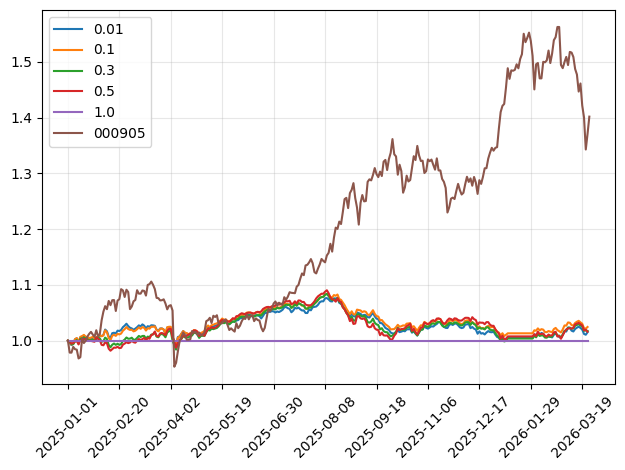

In [4]:
import matplotlib.pyplot as plt
import random

df_500 = pd.read_excel(f"{srcdir}/000905_SH.xlsx")
df_500.index = df_500["日期"].dt.strftime('%Y-%m-%d')
df_500.rename({"涨跌幅":"000905"},axis=1,inplace=True)

ret_df = pd.DataFrame(ret_dict,index=tr_filter_op[1:])
ret_df = ret_df.merge(df_500[["000905"]],left_index=True,right_index=True)
#ret_df = pd.DataFrame(ret_dict.items(),  # 键值对columns=["date", "value"]  # 列名你可以随便改).set_index("date")
temp = pd.DataFrame(0, index=["2025-01-01"], columns=ret_df.columns)
ret0_df = pd.concat([temp, ret_df], ignore_index=False)
ret_cum = (1 + ret0_df).cumprod()
# ret_cum.insert(0,0,0.9) #选
# ret_df.insert(0,0,0.9) #选

plt.plot(ret_cum,label=ret_cum.columns)
step = max(1, len(ret_cum) // 10)  # 最多显示10个刻度
plt.xticks(
    ticks=range(0, len(ret_cum), step),  # 按步长取刻度
    labels=ret_cum.index[::step],       # 对应标签
    rotation=45,                        # 标签倾斜45度（关键！）
    fontsize=10
)
plt.grid(alpha=0.3)  # 加网格更美观
plt.legend(loc='best')
plt.tight_layout()  # 自动适配布局，防止标签截断


# fig, ax1 = plt.subplots(figsize=(10, 6))
# ax1.plot(ret_cum.iloc[:, :-1], label=ret_cum.columns[:-1])
# ax1.legend(loc='best')
# ax1.grid(alpha=0.3)
# ax2 = ax1.twinx()
# ax2.plot(ret_cum.iloc[:, -1], color='red', label=ret_cum.columns[-1])
# ax2.legend(loc='upper right')
# # 统一X轴刻度（你原来的逻辑）
# step = max(1, len(ret_cum) // 10)
# ax1.set_xticks(range(0, len(ret_cum), step))
# ax1.set_xticklabels(ret_cum.index[::step], rotation=45, fontsize=10)
# plt.tight_layout()
# plt.show()
ret_cum

In [5]:
#简单回测一下业绩
rf = 0.015
res = []
ret_cum.dropna(how='any',inplace=True)
for i in range(ret_cum.shape[1]):
    port_nav = ret_cum.iloc[:,i]
    cum_ret = port_nav.iloc[-1] / port_nav.iloc[0] - 1
    ann_ret = (cum_ret + 1)**(252/len(port_nav)) - 1 #daily freq
    ann_vol = ret_df.iloc[:,i].std() * np.sqrt(252)
    sp = (ann_ret - rf) / ann_vol
    maxd = min(port_nav / port_nav.cummax()) - 1
    km = (ann_ret - rf) / abs(maxd) 
    result_dict = {
    '累计收益率': f'{float(cum_ret):.2%}',
    '年化收益率': f'{float(ann_ret):.2%}',
    '年化波动率': f'{float(ann_vol):.2%}',
    '夏普比率': f'{sp:.2f}',
    '最大回撤': f'{maxd:.2%}',
    '卡玛比率': f'{km:.2f}'}
    res.append(pd.Series(result_dict,name=ret_cum.columns[i]))

file_path = f"{spedir}/组合优化/minmax_不同std_净值.xlsx"
with pd.ExcelWriter(file_path, engine='openpyxl') as writer:
    # 第一个表：ret_cum → Sheet1
    ret_cum.to_excel(writer, sheet_name='净值', index=True)
    
    # 第二个表：backtest → Sheet2（你要的）
    pd.concat(res,axis=1).to_excel(writer, sheet_name='回测结果', index=True, header=True)

print("Excel 保存成功！两个工作表都已写入 ✅")

Excel 保存成功！两个工作表都已写入 ✅


C:\Windows\Temp\ipykernel_28276\2050027402.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  sp = (ann_ret - rf) / ann_vol
C:\Windows\Temp\ipykernel_28276\2050027402.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  km = (ann_ret - rf) / abs(maxd)
